In [2]:
# ===== 셀 1: 환경 설정 =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 한글 폰트
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
uf = pd.read_csv('unified_features.csv', index_col=0)
uf.index = uf.index.astype(int)
uf['fault_name'] = uf['fault_name'].str.strip()

# Batch 라벨 부여
def get_batch(wid):
    if wid < 3000: return 'Batch_29'
    elif wid < 3200: return 'Batch_31'
    else: return 'Batch_33'

uf['batch'] = uf.index.map(get_batch)

# 마스크 정의
is_normal = (uf['fault_name'] == 'calibration').values
is_fault = ~is_normal

# X 분리
X_full = uf.drop(columns=['fault_name', 'batch']).values
X_normal = X_full[is_normal]

print(f"전체: {X_full.shape}")
print(f"정상: {is_normal.sum()}장, Fault: {is_fault.sum()}장\n")

print("Batch별 분포:")
print(uf['batch'].value_counts().sort_index())

전체: (123, 8478)
정상: 103장, Fault: 20장

Batch별 분포:
batch
Batch_29    40
Batch_31    42
Batch_33    41
Name: count, dtype: int64


In [3]:
# ===== 셀 2: 공유 PCA 학습 =====
import re

# 공유 PCA 학습 (전체 정상 103장 — 학습 안정성 확보)
pca = PCA(n_components=0.90).fit(X_normal)
print(f"공유 PCA 주성분 수: {pca.n_components_}")
print(f"누적 분산: 90%")

# 컬럼 메타데이터 파싱 (블록명, 시점)
pattern = re.compile(r"^(RFM|OES|EV)__(.+)_t(\d+)$")
col_block = []
col_time = []
for col in uf.drop(columns=['fault_name','batch']).columns:
    m = pattern.match(col)
    if m:
        col_block.append(m.group(1))
        col_time.append(int(m.group(3)))

col_block = np.array(col_block)
col_time = np.array(col_time)

# 각 블록의 최대 시점 수
K = {
    'RFM': col_time[col_block=='RFM'].max() + 1,
    'OES': col_time[col_block=='OES'].max() + 1,
    'EV':  col_time[col_block=='EV'].max() + 1,
}
print(f"\n블록별 시점 수: {K}")

공유 PCA 주성분 수: 69
누적 분산: 90%

블록별 시점 수: {'RFM': np.int64(28), 'OES': np.int64(38), 'EV': np.int64(100)}


In [4]:
# ===== 셀 3: 시간 마스킹 함수 =====
def make_streaming_features(X, col_block, col_time, K, progress):
    """공정 진행률 progress(0~1)까지만 살리고 나머지는 0으로 마스킹"""
    X_masked = X.copy()
    for blk, n_t in K.items():
        cutoff = int(np.ceil(progress * n_t))
        mask = (col_block == blk) & (col_time >= cutoff)
        X_masked[:, mask] = 0  # autoscale 후 0 = 정상 평균
    return X_masked

def Q_stat(X, model):
    """Q 통계량 = 재구성 잔차"""
    X_recon = model.inverse_transform(model.transform(X))
    return ((X - X_recon)**2).sum(axis=1)

print("Streaming 함수 정의 완료")

Streaming 함수 정의 완료


In [5]:
# ===== 셀 4: 진행률 sweep, Q 점수 행렬 생성 =====
progress_list = np.arange(0.1, 1.01, 0.1)  # 10% ~ 100%

# Q_streaming[t, w] = 진행률 t에서 웨이퍼 w의 Q 점수
Q_streaming = np.zeros((len(progress_list), len(X_full)))

for i, p in enumerate(progress_list):
    X_p = make_streaming_features(X_full, col_block, col_time, K, p)
    Q_streaming[i] = Q_stat(X_p, pca)

print(f"Q_streaming shape: {Q_streaming.shape}")
print(f"  (진행률 {len(progress_list)}개 × 웨이퍼 {len(X_full)}장)")

Q_streaming shape: (10, 123)
  (진행률 10개 × 웨이퍼 123장)


In [6]:
# ===== 셀 5: Batch별 × 시점별 임계값 산출 =====
# 기존: thresholds[t] (시점별 1개)
# 새 방식: thresholds[t, batch] (시점별 × batch별)

batches = ['Batch_29', 'Batch_31', 'Batch_33']

# 임계값 딕셔너리: {batch: [thresh_t1, thresh_t2, ...]}
batch_thresholds = {}

print("=== Batch별 × 시점별 임계값 ===")
print(f"{'진행률':<8}" + "".join([f"{b:<14}" for b in batches]))
print("-" * 60)

for b in batches:
    mask_b_normal = (uf['batch']==b).values & is_normal
    thresholds_b = []
    for i in range(len(progress_list)):
        # 해당 batch의 정상 데이터의 99% 분위수 (시점별로)
        Q_b_normal_t = Q_streaming[i, mask_b_normal]
        threshold = np.quantile(Q_b_normal_t, 0.99)
        thresholds_b.append(threshold)
    batch_thresholds[b] = np.array(thresholds_b)

# 시점별 임계값 행렬 출력
for i, p in enumerate(progress_list):
    row = f"{int(p*100)}%      "
    for b in batches:
        row += f"{batch_thresholds[b][i]:>10.2f}    "
    print(row)

=== Batch별 × 시점별 임계값 ===
진행률     Batch_29      Batch_31      Batch_33      
------------------------------------------------------------
10%         1027.34       1142.94       1388.61    
20%         1679.97       1909.13       2328.97    
30%         2196.52       2371.38       3111.05    
40%         3511.35       2701.18       3551.09    
50%         3889.40       2710.74       4056.17    
60%         5802.99       2586.70       3978.37    
70%         5673.65       2162.60       3761.04    
80%         5425.54       1984.54       1943.74    
90%         5987.60       1766.63       1561.66    
100%         1926.98       1698.24       1264.41    


In [7]:
# ===== 셀 6: Batch별 임계값으로 탐지 시점 추적 =====
detection_progress = np.full(len(X_full), np.nan)

batch_labels = uf['batch'].values

for w_idx in range(len(X_full)):
    # 이 웨이퍼의 batch
    w_batch = batch_labels[w_idx]
    # 이 batch의 시점별 임계값 사용
    thresholds_w = batch_thresholds[w_batch]

    # 첫 임계값 초과 시점 찾기
    for t_idx, p in enumerate(progress_list):
        if Q_streaming[t_idx, w_idx] > thresholds_w[t_idx]:
            detection_progress[w_idx] = p
            break

# 결과 정리
detection_df = pd.DataFrame({
    'wafer_id': uf.index,
    'fault_name': uf['fault_name'].values,
    'batch': batch_labels,
    'is_fault': is_fault,
    'detected_at_pct': detection_progress * 100,
    'lead_time_pct': (1 - detection_progress) * 100,
})

# Fault만 따로
fault_results = detection_df[detection_df['is_fault']].sort_values('detected_at_pct')
print("=== Fault 탐지 시점 ===")
print(fault_results.to_string(index=False))

=== Fault 탐지 시점 ===
 wafer_id fault_name    batch  is_fault  detected_at_pct  lead_time_pct
     2915    TCP +50 Batch_29      True             10.0           90.0
     2917     RF +10 Batch_29      True             10.0           90.0
     2918      Pr +3 Batch_29      True             10.0           90.0
     2938      Pr -2 Batch_29      True             10.0           90.0
     3142      Pr +2 Batch_31      True             10.0           90.0
     3141    BCl3 -5 Batch_31      True             10.0           90.0
     3122      RF +8 Batch_31      True             10.0           90.0
     3120    TCP +30 Batch_31      True             10.0           90.0
     3318    TCP -15 Batch_33      True             10.0           90.0
     3143    TCP -20 Batch_31      True             10.0           90.0
     3340      Pr +1 Batch_33      True             10.0           90.0
     3339   BCl3 +10 Batch_33      True             10.0           90.0
     3341    TCP +20 Batch_33      True     

In [8]:
# ===== 셀 7: 성능 평가 =====
n_fault = is_fault.sum()
n_normal = is_normal.sum()

detected = ~np.isnan(detection_progress)

# Fault 탐지 성능
tp = (detected & is_fault).sum()
fn = (~detected & is_fault).sum()

# Streaming에서의 False Positive: 정상이 100% 전에 임계값 초과
fp_streaming = (detected & is_normal).sum()
tn_streaming = (~detected & is_normal).sum()

print("="*60)
print("Batch-aware Streaming MPCA 성능")
print("="*60)
print(f"\nFault 탐지: {tp}/{n_fault} (Recall {tp/n_fault*100:.1f}%)")
print(f"False Negative: {fn}")
print(f"\n정상 데이터:")
print(f"  탐지된 (FP): {fp_streaming}/{n_normal} (FAR {fp_streaming/n_normal*100:.1f}%)")
print(f"  안 탐지: {tn_streaming}")

# Lead Time
lead_times = (1 - detection_progress[is_fault]) * 100
lead_times_valid = lead_times[~np.isnan(lead_times)]
print(f"\nLead Time (탐지된 fault만):")
print(f"  평균: {lead_times_valid.mean():.1f}%")
print(f"  중앙값: {np.median(lead_times_valid):.1f}%")
print(f"  최소: {lead_times_valid.min():.1f}%")
print(f"  최대: {lead_times_valid.max():.1f}%")

# Batch별 FAR
print(f"\nBatch별 정상 탐지 (FP):")
for b in batches:
    mask = (uf['batch']==b).values & is_normal
    far = (detected[mask]).mean() * 100
    print(f"  {b}: {(detected[mask]).sum()}/{mask.sum()} = {far:.1f}%")

Batch-aware Streaming MPCA 성능

Fault 탐지: 20/20 (Recall 100.0%)
False Negative: 0

정상 데이터:
  탐지된 (FP): 9/103 (FAR 8.7%)
  안 탐지: 94

Lead Time (탐지된 fault만):
  평균: 76.5%
  중앙값: 90.0%
  최소: 0.0%
  최대: 90.0%

Batch별 정상 탐지 (FP):
  Batch_29: 2/32 = 6.2%
  Batch_31: 4/36 = 11.1%
  Batch_33: 3/35 = 8.6%


In [9]:
# ===== 셀 8: 기존 streaming MPCA와 비교 =====
# 기존 방식: 시점별 공통 임계값
thresholds_global = np.zeros(len(progress_list))
for i in range(len(progress_list)):
    thresholds_global[i] = np.quantile(Q_streaming[i, is_normal], 0.99)

# 기존 방식 탐지
detection_global = np.full(len(X_full), np.nan)
for w_idx in range(len(X_full)):
    for t_idx, p in enumerate(progress_list):
        if Q_streaming[t_idx, w_idx] > thresholds_global[t_idx]:
            detection_global[w_idx] = p
            break

# 비교
detected_global = ~np.isnan(detection_global)
detected_aware = ~np.isnan(detection_progress)

print("="*60)
print("기존 vs Batch-aware Streaming 비교")
print("="*60)
print(f"\n{'지표':<25} {'기존':<15} {'Batch-aware':<15}")
print("-" * 60)

# Recall
recall_global = (detected_global & is_fault).sum() / n_fault * 100
recall_aware = (detected_aware & is_fault).sum() / n_fault * 100
print(f"{'Recall':<25} {recall_global:.1f}%          {recall_aware:.1f}%")

# 전체 FAR
far_global = (detected_global & is_normal).sum() / n_normal * 100
far_aware = (detected_aware & is_normal).sum() / n_normal * 100
print(f"{'전체 FAR':<25} {far_global:.1f}%          {far_aware:.1f}%")

# Lead Time
lt_global = ((1 - detection_global[is_fault & detected_global]) * 100).mean()
lt_aware = ((1 - detection_progress[is_fault & detected_aware]) * 100).mean()
print(f"{'평균 Lead Time':<25} {lt_global:.1f}%          {lt_aware:.1f}%")

# Batch별 FAR
print(f"\nBatch별 FAR 비교:")
print(f"{'Batch':<12} {'기존':<15} {'Batch-aware':<15}")
print("-" * 45)
for b in batches:
    mask = (uf['batch']==b).values & is_normal
    far_g = (detected_global[mask]).mean() * 100
    far_a = (detected_aware[mask]).mean() * 100
    print(f"  {b:<10} {far_g:<10.1f}%   {far_a:<10.1f}%")

# Chi-square로 batch 균등성 검정
from scipy.stats import chi2_contingency
cont_global = []
cont_aware = []
for b in batches:
    mask = (uf['batch']==b).values & is_normal
    fp_g = (detected_global[mask]).sum()
    fp_a = (detected_aware[mask]).sum()
    cont_global.append([fp_g, mask.sum() - fp_g])
    cont_aware.append([fp_a, mask.sum() - fp_a])

_, p_global, _, _ = chi2_contingency(np.array(cont_global))
_, p_aware, _, _ = chi2_contingency(np.array(cont_aware))
print(f"\nBatch 간 FAR 균등성 (Chi-square):")
print(f"  기존:        p = {p_global:.4f}")
print(f"  Batch-aware: p = {p_aware:.4f}")

기존 vs Batch-aware Streaming 비교

지표                        기존              Batch-aware    
------------------------------------------------------------
Recall                    100.0%          100.0%
전체 FAR                    6.8%          8.7%
평균 Lead Time              72.5%          76.5%

Batch별 FAR 비교:
Batch        기존              Batch-aware    
---------------------------------------------
  Batch_29   12.5      %   6.2       %
  Batch_31   0.0       %   11.1      %
  Batch_33   8.6       %   8.6       %

Batch 간 FAR 균등성 (Chi-square):
  기존:        p = 0.1085
  Batch-aware: p = 0.7773


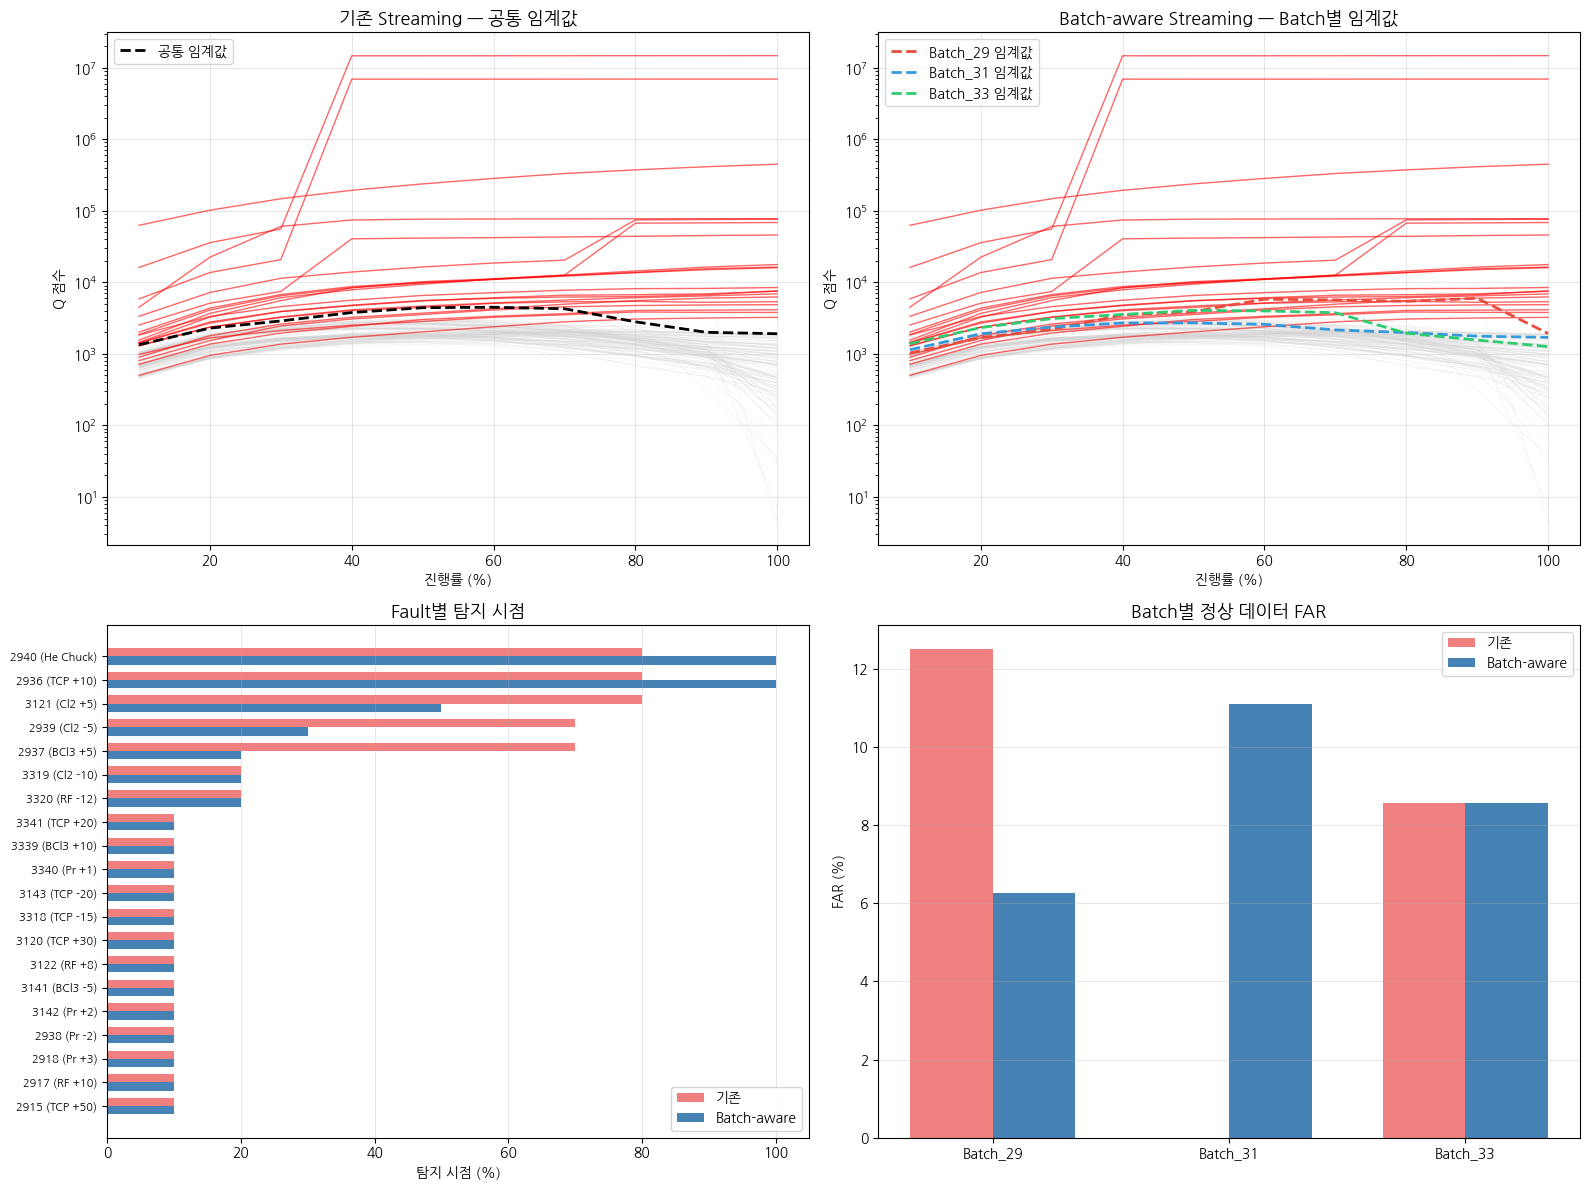

In [10]:
# ===== 셀 9: 시각화 =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 기존 — 시점별 공통 임계값과 fault 궤적
ax = axes[0, 0]
for w_idx in np.where(is_normal)[0]:
    ax.plot(progress_list * 100, Q_streaming[:, w_idx],
            color='lightgray', alpha=0.3, linewidth=0.5)
for w_idx in np.where(is_fault)[0]:
    ax.plot(progress_list * 100, Q_streaming[:, w_idx],
            color='red', alpha=0.6, linewidth=1)
ax.plot(progress_list * 100, thresholds_global,
        'k--', linewidth=2, label='공통 임계값')
ax.set_xlabel('진행률 (%)')
ax.set_ylabel('Q 점수')
ax.set_title('기존 Streaming — 공통 임계값', fontsize=13)
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

# 2. Batch-aware — 시점별 × Batch별 임계값
ax = axes[0, 1]
for w_idx in np.where(is_normal)[0]:
    ax.plot(progress_list * 100, Q_streaming[:, w_idx],
            color='lightgray', alpha=0.3, linewidth=0.5)
for w_idx in np.where(is_fault)[0]:
    ax.plot(progress_list * 100, Q_streaming[:, w_idx],
            color='red', alpha=0.6, linewidth=1)
colors_b = {'Batch_29':'#e74c3c', 'Batch_31':'#3498db', 'Batch_33':'#2ecc71'}
for b in batches:
    ax.plot(progress_list * 100, batch_thresholds[b],
            '--', color=colors_b[b], linewidth=2, label=f'{b} 임계값')
ax.set_xlabel('진행률 (%)')
ax.set_ylabel('Q 점수')
ax.set_title('Batch-aware Streaming — Batch별 임계값', fontsize=13)
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

# 3. Fault별 탐지 시점 비교
ax = axes[1, 0]
fault_df = detection_df[is_fault].copy()
fault_df['detected_global'] = (1 - detection_global[is_fault]) * 100
fault_df_sorted = fault_df.sort_values('detected_at_pct')

x_pos = range(len(fault_df_sorted))
width = 0.35
ax.barh([i+width/2 for i in x_pos], 100 - fault_df_sorted['detected_global'],
        width, label='기존', color='lightcoral')
ax.barh([i-width/2 for i in x_pos], fault_df_sorted['detected_at_pct'],
        width, label='Batch-aware', color='steelblue')
ax.set_yticks(x_pos)
ax.set_yticklabels([f"{r['wafer_id']} ({r['fault_name']})"
                    for _, r in fault_df_sorted.iterrows()], fontsize=8)
ax.set_xlabel('탐지 시점 (%)')
ax.set_title('Fault별 탐지 시점', fontsize=13)
ax.legend()
ax.grid(alpha=0.3, axis='x')

# 4. Batch별 FAR 비교 막대 차트
ax = axes[1, 1]
x = np.arange(len(batches))
width = 0.35
far_g_vals = [(detected_global[(uf['batch']==b).values & is_normal]).mean()*100 for b in batches]
far_a_vals = [(detected_aware[(uf['batch']==b).values & is_normal]).mean()*100 for b in batches]
ax.bar(x - width/2, far_g_vals, width, label='기존', color='lightcoral')
ax.bar(x + width/2, far_a_vals, width, label='Batch-aware', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(batches)
ax.set_ylabel('FAR (%)')
ax.set_title('Batch별 정상 데이터 FAR', fontsize=13)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('batch_aware_streaming_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# ===== 셀 10: 결과 저장 =====
detection_df['detected_global_pct'] = (1 - detection_global) * 100
detection_df['lead_time_global'] = (1 - detection_global) * 100
detection_df.to_csv('batch_aware_streaming_results.csv', index=False)

# 임계값 행렬 저장
threshold_matrix = pd.DataFrame({
    'progress_pct': progress_list * 100,
    'threshold_global': thresholds_global,
    'threshold_Batch_29': batch_thresholds['Batch_29'],
    'threshold_Batch_31': batch_thresholds['Batch_31'],
    'threshold_Batch_33': batch_thresholds['Batch_33'],
})
threshold_matrix.to_csv('batch_aware_thresholds.csv', index=False)

print("저장 완료:")
print("  batch_aware_streaming_results.csv  — 탐지 결과")
print("  batch_aware_thresholds.csv         — 시점별 × Batch별 임계값")
print("  batch_aware_streaming_comparison.png — 비교 시각화")

저장 완료:
  batch_aware_streaming_results.csv  — 탐지 결과
  batch_aware_thresholds.csv         — 시점별 × Batch별 임계값
  batch_aware_streaming_comparison.png — 비교 시각화
